In [1]:
import os
import time
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
import jax
import jax.numpy as jnp
import optax
from jax.scipy.spatial.transform import Rotation
from orbax.checkpoint import PyTreeCheckpointer
from flax.training.train_state import TrainState
from matplotlib import pyplot as plt

from lotf import LOTF_PATH
from lotf.envs import HoveringStateEnv, rollout
from lotf.envs.wrappers import MinMaxObservationWrapper
from lotf.modules import MLP, LatentConditionedResidualDynamics
from lotf.objects import Quadrotor

%matplotlib inline

# Training Latent-Conditioned Residual Dynamics

## 1. Seed

In [2]:
seed = 0
key = jax.random.key(seed)
key_init, key_bptt = jax.random.split(key, 2)

## 2. Define Simulation Dynamics Config

In [3]:
# simulation dynamics config
sim_dyn_config = {
    "use_high_fidelity": True,           # stand-in for the disturbed/real system
    "use_forward_residual": False,       # whether to use residual dynamics in forward simulation
}

# No residual parameters are read when use_forward_residual=False. Passing an
# empty pytree avoids restoring the legacy CUDA-sharded dummy checkpoint.
dummy_residual_params = {}

## 3. Create Quadrotor Object and Data-Collection Environment

In [4]:
# simulation parameters
sim_dt = 0.02
max_sim_time = 5.0

# quadrotor object
quad_obj = Quadrotor.from_name("example_quad", sim_dyn_config)

eval_env = HoveringStateEnv(
    max_steps_in_episode=int(max_sim_time / sim_dt),
    dt=sim_dt,
    delay=0.04,
    quad_obj=quad_obj,
    margin=0.5,
    hover_target=[1.5, 0.0, 1.5],
)
eval_env = MinMaxObservationWrapper(eval_env)

# get dims
action_dim = eval_env.action_space.shape[0]
obs_dim = eval_env.observation_space.shape[0]

print("====== eval_env info ======")
print(f"action_dim: {action_dim}")
print(f"obs_dim: {obs_dim}")

====== eval_env info ======
action_dim: 4
obs_dim: 27


## 4. Load the Trained Policy

In [5]:
policy_name = "state_hovering_params"

# create policy network
base_policy_net = MLP(
    [obs_dim, 512, 512, action_dim],
    action_bias=eval_env.hovering_action,
)

path = LOTF_PATH + "/../checkpoints/policy/" + policy_name
ckptr = PyTreeCheckpointer()
base_policy_params = ckptr.restore(path)
loaded_train_state = TrainState.create(apply_fn=base_policy_net.apply, params=base_policy_params, tx=optax.adam(1e-3))

# define policy function
def policy_trained(obs, key):
    return loaded_train_state.apply_fn(loaded_train_state.params, obs)

/home/dimitria/venvs/diff-sim-env/lib/python3.12/site-packages/orbax/checkpoint/type_handlers.py:1330: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


## 5. Collect the Transition Dataset

In [6]:
# The paper stores raw (s_t, a_t, s_{t+1}) transitions. The fixed latent and
# wind condition selected at reset are retained with every transition.
num_rollouts = 256
key, key_rollouts = jax.random.split(key)
rollout_keys = jax.random.split(key_rollouts, num_rollouts)
parallel_rollout = jax.vmap(rollout, in_axes=(None, 0, None, None))
trajectories = parallel_rollout(
    eval_env, rollout_keys, policy_trained, dummy_residual_params
)

env_states = trajectories.state
quad_states = env_states.quadrotor_state

# Convert rotation matrices to the paper's state convention: (p, q, v).
def state_vectors(position, rotation_matrix, velocity):
    quaternion_xyzw = Rotation.from_matrix(rotation_matrix).as_quat()
    quaternion_wxyz = jnp.concatenate(
        [quaternion_xyzw[..., 3:], quaternion_xyzw[..., :3]], axis=-1
    )
    return jnp.concatenate([position, quaternion_wxyz, velocity], axis=-1)

states = state_vectors(
    quad_states.p[:, :-1], quad_states.R[:, :-1], quad_states.v[:, :-1]
)
next_states = state_vectors(
    quad_states.p[:, 1:], quad_states.R[:, 1:], quad_states.v[:, 1:]
)

# The action chosen from s_t is stored at the end of the successor state's
# action buffer, hence the 1: alignment below.
actions = env_states.last_actions[:, 1:, -1, :]
latent_z = env_states.latent_z[:, :-1, :]
wind_velocity = env_states.wind_velocity[:, :-1, :]
state_actions = jnp.concatenate([states, actions], axis=-1)

# rollout(..., real_step=False) does not auto-reset. Keep the terminal
# transition itself, but discard any subsequent out-of-episode transitions.
done = jnp.logical_or(
    trajectories.terminated[:, 1:], trajectories.truncated[:, 1:]
)
valid_transition = (jnp.cumsum(done, axis=1) - done) == 0

dataset = {
    "state": states[valid_transition],
    "action": actions[valid_transition],
    "state_action": state_actions[valid_transition],
    "next_state": next_states[valid_transition],
    "latent_z": latent_z[valid_transition],
    "wind_velocity": wind_velocity[valid_transition],
}

assert dataset["state"].shape[-1] == 10
assert dataset["action"].shape[-1] == 4
assert dataset["state_action"].shape[-1] == 14
assert dataset["latent_z"].shape[-1] == 12
assert jnp.all(env_states.latent_z == env_states.latent_z[:, :1, :])

_, samples_per_wind = jnp.unique(
    dataset["wind_velocity"], axis=0, return_counts=True
)
print(f"Collected {dataset['state'].shape[0]:,} transitions")
print(f"Conditions represented: {samples_per_wind.shape[0]}/17")
print(f"Samples per represented condition: {samples_per_wind}")

Collected 64,000 transitions
Conditions represented: 17/17
Samples per represented condition: [3750 4500 3750 3500 3750 3500 2250 4000 2500 4500 2750 4250 3500 5250
 5000 2000 5250]


## 6. Instantiate the Latent-Conditioned Residual Model

In [7]:
# The paper's hovering model predicts position and velocity corrections only.
# It uses a 12-D latent, two 256-unit FiLM blocks, and GELU activations.
residual_model = LatentConditionedResidualDynamics(
    state_action_dim=dataset["state_action"].shape[-1],
    latent_dim=dataset["latent_z"].shape[-1],
    hidden_dim=256,
    num_blocks=2,
    predict_orientation=False,
)

key, key_model = jax.random.split(key)
residual_params = residual_model.initialize(key_model)
residual_train_state = TrainState.create(
    apply_fn=residual_model.apply,
    params=residual_params,
    tx=optax.adam(learning_rate=3e-4),
)

dummy_prediction = residual_model.apply(
    residual_train_state.params,
    dataset["state_action"][0],
    dataset["latent_z"][0],
)
assert dummy_prediction.shape == (6,)
print(f"Residual output shape: {dummy_prediction.shape}")

Residual output shape: (6,)


## 7. Compute Residual Targets and Minimize $L_{dyn}$

In [8]:
# Build the analytical rigid-body prior used in the paper. Using _step keeps
# its control-delay handling exactly aligned with the collected transitions.
prior_dyn_config = {
    "use_high_fidelity": False,
    "use_forward_residual": False,
}
prior_env = HoveringStateEnv(
    max_steps_in_episode=int(max_sim_time / sim_dt),
    dt=sim_dt,
    delay=0.04,
    quad_obj=Quadrotor.from_name("example_quad", prior_dyn_config),
    margin=0.5,
    hover_target=[1.5, 0.0, 1.5],
)

# Recover the full pre-transition states in the same order as the flattened
# dataset so the prior sees the correct action history and physical state.
transition_states = jax.tree.map(
    lambda leaf: leaf[:, :-1][valid_transition], env_states
)
observed_next_quad_states = jax.tree.map(
    lambda leaf: leaf[:, 1:][valid_transition], quad_states
)
key, key_prior = jax.random.split(key)
prior_keys = jax.random.split(key_prior, dataset["state"].shape[0])

@jax.jit
def evaluate_prior(states, actions, keys):
    def prior_step(state, action, step_key):
        transition = prior_env._step(state, action, {}, step_key)
        return transition.state.quadrotor_state

    return jax.vmap(prior_step)(states, actions, keys)

prior_next_quad_states = evaluate_prior(
    transition_states, dataset["action"], prior_keys
)

def state_difference(observed, nominal, include_orientation=False):
    # Position and velocity live in Euclidean space and use subtraction.
    differences = [observed.p - nominal.p, observed.v - nominal.v]
    if include_orientation:
        # Never subtract quaternions. For R_pred = R_prior Exp(delta_xi),
        # the correct target is Log(R_prior^T R_observed) in R^3.
        relative_rotation = (
            jnp.swapaxes(nominal.R, -1, -2) @ observed.R
        )
        delta_orientation = Rotation.from_matrix(
            relative_rotation
        ).as_rotvec()
        differences.append(delta_orientation)
    return jnp.concatenate(differences, axis=-1)

residual_targets = state_difference(
    observed_next_quad_states,
    prior_next_quad_states,
    include_orientation=residual_model.predict_orientation,
)
assert residual_targets.shape == (dataset["state"].shape[0], 6)

# Split before computing normalization statistics. The paper normalizes
# state-action inputs using statistics from the training buffer.
num_samples = residual_targets.shape[0]
key, key_split = jax.random.split(key)
permutation = jax.random.permutation(key_split, num_samples)
num_train = int(0.9 * num_samples)
train_indices = permutation[:num_train]
validation_indices = permutation[num_train:]

input_mean = dataset["state_action"][train_indices].mean(axis=0)
input_std = dataset["state_action"][train_indices].std(axis=0)
input_std = jnp.maximum(input_std, 1e-6)
normalized_inputs = (dataset["state_action"] - input_mean) / input_std

train_inputs = normalized_inputs[train_indices]
train_latents = dataset["latent_z"][train_indices]
train_targets = residual_targets[train_indices]
validation_inputs = normalized_inputs[validation_indices]
validation_latents = dataset["latent_z"][validation_indices]
validation_targets = residual_targets[validation_indices]

huber_delta = 1.0
batch_size = min(2048, num_train)
num_training_steps = 5000

def dynamics_loss(params, inputs, latents, targets):
    predictions = residual_model.apply(params, inputs, latents)
    # Mean over both transitions and residual coordinates implements L_dyn.
    return optax.huber_loss(
        predictions, targets, delta=huber_delta
    ).mean()

@jax.jit
def train_residual_model(train_state, rng_key):
    def training_step(carry, _):
        state, step_key = carry
        step_key, sample_key = jax.random.split(step_key)
        batch_indices = jax.random.randint(
            sample_key, (batch_size,), 0, train_inputs.shape[0]
        )

        loss, gradients = jax.value_and_grad(dynamics_loss)(
            state.params,
            train_inputs[batch_indices],
            train_latents[batch_indices],
            train_targets[batch_indices],
        )
        state = state.apply_gradients(grads=gradients)
        return (state, step_key), loss

    (train_state, _), losses = jax.lax.scan(
        training_step, (train_state, rng_key), None, num_training_steps
    )
    return train_state, losses

key, key_train = jax.random.split(key)
compiled_train_residual_model = train_residual_model.lower(
    residual_train_state, key_train
).compile()
training_start_time = time.perf_counter()
residual_train_state, training_losses = compiled_train_residual_model(
    residual_train_state, key_train
)
training_losses.block_until_ready()
training_duration_seconds = time.perf_counter() - training_start_time
validation_loss = dynamics_loss(
    residual_train_state.params,
    validation_inputs,
    validation_latents,
    validation_targets,
)

print(f"Initial minibatch L_dyn: {training_losses[0]:.6e}")
print(f"Final minibatch L_dyn:   {training_losses[-1]:.6e}")
print(f"Validation L_dyn:        {validation_loss:.6e}")
print(f"Training time:           {training_duration_seconds:.2f} s")

Initial minibatch L_dyn: 8.725482e-03
Final minibatch L_dyn:   1.875989e-06
Validation L_dyn:        2.712200e-06
Training time:           1.46 s


## 8. Plot $L_{dyn}$ over Training Time

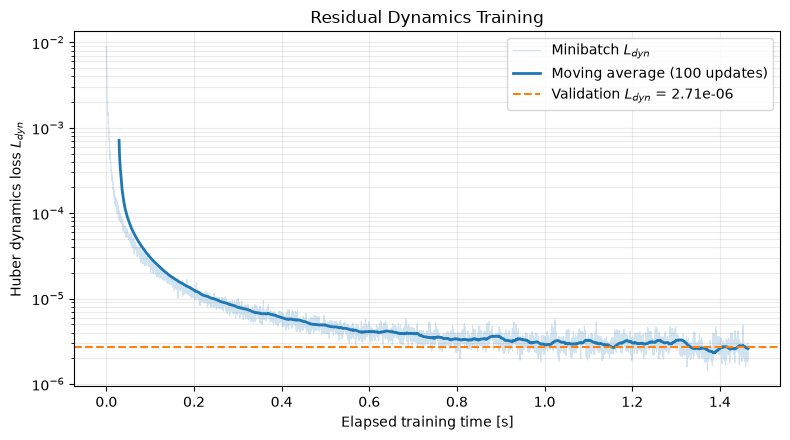

In [9]:
# lax.scan returns one loss per optimizer update. Distribute the measured
# compiled runtime over those updates to obtain elapsed training time.
elapsed_training_time = jnp.linspace(
    0.0, training_duration_seconds, training_losses.shape[0]
)
loss_for_plot = jnp.maximum(training_losses, 1e-12)

smoothing_window = min(100, training_losses.shape[0])
smoothing_kernel = jnp.ones(smoothing_window) / smoothing_window
smoothed_loss = jnp.convolve(
    loss_for_plot, smoothing_kernel, mode="valid"
)
smoothed_time = elapsed_training_time[smoothing_window - 1:]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    elapsed_training_time, loss_for_plot,
    color="tab:blue", alpha=0.2, linewidth=0.8, label="Minibatch $L_{dyn}$"
)
ax.plot(
    smoothed_time, smoothed_loss,
    color="tab:blue", linewidth=2.0,
    label=f"Moving average ({smoothing_window} updates)"
)
ax.axhline(
    validation_loss, color="tab:orange", linestyle="--",
    label=f"Validation $L_{{dyn}}$ = {validation_loss:.2e}"
)
ax.set_xlabel("Elapsed training time [s]")
ax.set_ylabel("Huber dynamics loss $L_{dyn}$")
ax.set_yscale("log")
ax.set_title("Residual Dynamics Training")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## 9. Test Five Hidden Wind Conditions at the Same State

In [10]:
# Use calm and the four cardinal unit-speed winds. Each row retrieves the
# immutable latent associated with that wind; wind itself is not a model input.
test_condition_indices = jnp.array([0, 1, 3, 5, 7])
test_pairs = eval_env.wind_z_table[test_condition_indices]
test_wind_velocities = test_pairs[:, :3]
test_latents = test_pairs[:, 3:]

# Hold s_t and a_t exactly fixed across all five tests.
fixed_state_action = dataset["state_action"][validation_indices[0]]
fixed_normalized_input = (fixed_state_action - input_mean) / input_std
fixed_inputs = jnp.broadcast_to(
    fixed_normalized_input, (test_condition_indices.shape[0], 14)
)

test_residual_predictions = residual_model.apply(
    residual_train_state.params, fixed_inputs, test_latents
)

# Five explicit tests: every wind-associated prediction must differ from
# all four predictions produced for the other hidden conditions.
prediction_tolerance = 1e-6
for test_idx in range(test_condition_indices.shape[0]):
    other_predictions = jnp.concatenate(
        [
            test_residual_predictions[:test_idx],
            test_residual_predictions[test_idx + 1:],
        ],
        axis=0,
    )
    distances = jnp.linalg.norm(
        other_predictions - test_residual_predictions[test_idx], axis=-1
    )
    assert jnp.all(distances > prediction_tolerance), (
        f"Condition {test_idx} produced a collapsed residual prediction. "
        "The training data may not contain condition-dependent dynamics."
    )

assert jnp.unique(test_wind_velocities, axis=0).shape[0] == 5
assert jnp.unique(test_latents, axis=0).shape[0] == 5

print(f"Fixed state-action: {fixed_state_action}")
for wind, prediction in zip(test_wind_velocities, test_residual_predictions):
    print(f"wind={wind} -> predicted [delta_p, delta_v]={prediction}")
print("All five hidden-condition tests passed.")

Fixed state-action: [ 1.0312414   0.44788527  1.5934352   0.98691833  0.04696371  0.04972029
 -0.14599507  0.5853677  -0.42636228  0.3225888   1.4283831  -0.25682217
 -0.47241044  0.01146896]
wind=[0. 0. 0.] -> predicted [delta_p, delta_v]=[ 0.00091076  0.00257319 -0.00805135  0.00213999  0.00181081  0.04798807]
wind=[1. 0. 0.] -> predicted [delta_p, delta_v]=[-0.00303591 -0.00079797  0.00255486  0.00052002  0.00118991  0.04424051]
wind=[-4.371139e-08  1.000000e+00  0.000000e+00] -> predicted [delta_p, delta_v]=[ 0.00293271 -0.00150424 -0.00453319  0.00013937  0.00623737  0.04630985]
wind=[-1.000000e+00 -8.742278e-08  0.000000e+00] -> predicted [delta_p, delta_v]=[ 0.00313877 -0.00016865 -0.01027329  0.00518248  0.00061635  0.04659544]
wind=[ 1.1924881e-08 -1.0000000e+00  0.0000000e+00] -> predicted [delta_p, delta_v]=[-0.00448605  0.00305292 -0.00345323 -0.00433369  0.00379053  0.0479053 ]
All five hidden-condition tests passed.


## 10. Evaluate Predicted Residuals on Fresh Policy Rollouts

Held-out transitions: 16,000
Learned-model Huber L_dyn: 1.722838e-05
Zero-residual Huber loss:   6.095970e-05
delta_px: MAE=1.471e-03, RMSE=4.002e-03, R2=-30268.441
delta_py: MAE=1.595e-03, RMSE=4.098e-03, R2=-35437.301
delta_pz: MAE=1.405e-03, RMSE=3.651e-03, R2=-199.189
delta_vx: MAE=1.804e-03, RMSE=4.462e-03, R2=-2.749
delta_vy: MAE=1.505e-03, RMSE=3.923e-03, R2=-2.246
delta_vz: MAE=4.295e-03, RMSE=1.119e-02, R2=0.809


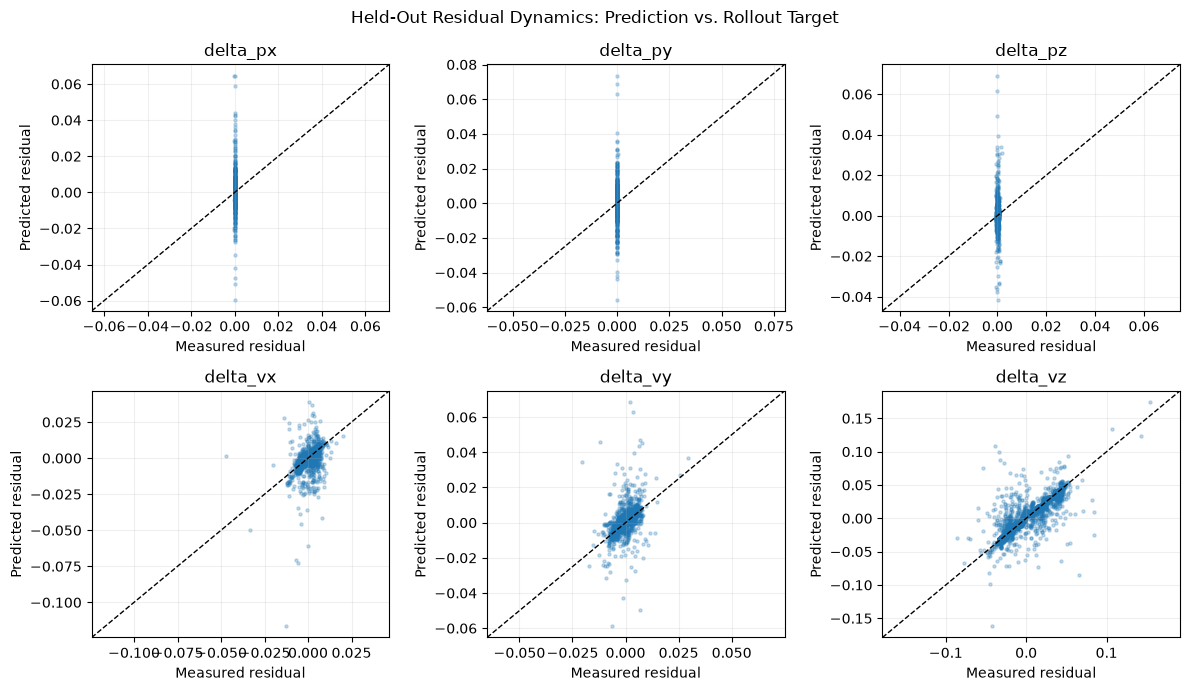

In [11]:
# Generate a held-out dataset with RNG keys that were never used for training.
num_test_rollouts = 64
key, key_test_rollouts = jax.random.split(key)
test_rollout_keys = jax.random.split(key_test_rollouts, num_test_rollouts)
test_trajectories = parallel_rollout(
    eval_env, test_rollout_keys, policy_trained, dummy_residual_params
)

test_env_states = test_trajectories.state
test_quad_states = test_env_states.quadrotor_state
test_states = state_vectors(
    test_quad_states.p[:, :-1],
    test_quad_states.R[:, :-1],
    test_quad_states.v[:, :-1],
)
test_actions = test_env_states.last_actions[:, 1:, -1, :]
test_state_actions = jnp.concatenate([test_states, test_actions], axis=-1)
test_done = jnp.logical_or(
    test_trajectories.terminated[:, 1:],
    test_trajectories.truncated[:, 1:],
)
test_valid_transition = (jnp.cumsum(test_done, axis=1) - test_done) == 0

# Evaluate the analytical prior from exactly the same pre-transition states.
test_transition_states = jax.tree.map(
    lambda leaf: leaf[:, :-1][test_valid_transition], test_env_states
)
test_observed_next_quad_states = jax.tree.map(
    lambda leaf: leaf[:, 1:][test_valid_transition], test_quad_states
)
test_actions = test_actions[test_valid_transition]
test_state_actions = test_state_actions[test_valid_transition]
test_latent_z = test_env_states.latent_z[:, :-1][test_valid_transition]

key, key_test_prior = jax.random.split(key)
test_prior_keys = jax.random.split(
    key_test_prior, test_state_actions.shape[0]
)
test_prior_next_quad_states = evaluate_prior(
    test_transition_states, test_actions, test_prior_keys
)

# Ground-truth held-out residual: s_next minus the analytical prior. For
# hovering this is Euclidean position and velocity difference.
test_residual_targets = state_difference(
    test_observed_next_quad_states,
    test_prior_next_quad_states,
    include_orientation=residual_model.predict_orientation,
)
test_normalized_inputs = (test_state_actions - input_mean) / input_std
test_residual_predictions = residual_model.apply(
    residual_train_state.params, test_normalized_inputs, test_latent_z
)

# Quantitative comparison against both ground truth and a zero-residual model.
test_errors = test_residual_predictions - test_residual_targets
test_huber_loss = optax.huber_loss(
    test_residual_predictions, test_residual_targets, delta=huber_delta
).mean()
zero_model_huber_loss = optax.huber_loss(
    jnp.zeros_like(test_residual_targets),
    test_residual_targets,
    delta=huber_delta,
).mean()
component_mae = jnp.mean(jnp.abs(test_errors), axis=0)
component_rmse = jnp.sqrt(jnp.mean(test_errors**2, axis=0))
sum_squared_error = jnp.sum(test_errors**2, axis=0)
sum_squared_total = jnp.sum(
    (test_residual_targets - test_residual_targets.mean(axis=0)) ** 2,
    axis=0,
)
component_r2 = 1.0 - sum_squared_error / jnp.maximum(
    sum_squared_total, 1e-12
)

assert test_residual_predictions.shape == test_residual_targets.shape
assert jnp.all(jnp.isfinite(test_residual_predictions))
assert test_huber_loss < zero_model_huber_loss, (
    "The learned residual model does not outperform the analytical prior "
    "on fresh rollouts."
)

component_names = ["delta_px", "delta_py", "delta_pz",
                   "delta_vx", "delta_vy", "delta_vz"]
print(f"Held-out transitions: {test_residual_targets.shape[0]:,}")
print(f"Learned-model Huber L_dyn: {test_huber_loss:.6e}")
print(f"Zero-residual Huber loss:   {zero_model_huber_loss:.6e}")
for name, mae, rmse, r2 in zip(
    component_names, component_mae, component_rmse, component_r2
):
    print(f"{name:>8s}: MAE={mae:.3e}, RMSE={rmse:.3e}, R2={r2:.3f}")

# Predicted-versus-measured residual parity plots.
plot_stride = max(1, test_residual_targets.shape[0] // 5000)
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for component_idx, (axis, component_name) in enumerate(
    zip(axes.flat, component_names)
):
    target_component = test_residual_targets[::plot_stride, component_idx]
    predicted_component = test_residual_predictions[::plot_stride, component_idx]
    lower = float(jnp.minimum(target_component.min(), predicted_component.min()))
    upper = float(jnp.maximum(target_component.max(), predicted_component.max()))
    padding = max(0.05 * (upper - lower), 1e-9)
    axis.scatter(
        target_component, predicted_component, s=5, alpha=0.25
    )
    axis.plot(
        [lower - padding, upper + padding],
        [lower - padding, upper + padding],
        "k--", linewidth=1, label="Ideal"
    )
    axis.set_xlim(lower - padding, upper + padding)
    axis.set_ylim(lower - padding, upper + padding)
    axis.set_title(component_name)
    axis.set_xlabel("Measured residual")
    axis.set_ylabel("Predicted residual")
    axis.grid(True, alpha=0.2)

fig.suptitle("Held-Out Residual Dynamics: Prediction vs. Rollout Target")
fig.tight_layout()
plt.show()